<a href="https://colab.research.google.com/github/harshavardhannaidu4/ITA0651/blob/main/ita06_machine_learning_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.Implement and demonstrate the FIND-S algorithm for finding the most specific hypothesis
based on a given set of training data samples.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 1st_ml.csv to 1st_ml.csv


In [ ]:
# FIND-S Algorithm using CSV

import pandas as pd

# Load dataset
data = pd.read_csv("1st_ml.csv")

print("Dataset:\n")
print(data)


# Convert to list
data_list = data.values.tolist()


# Initialize hypothesis
hypothesis = ['0'] * (len(data_list[0]) - 1)

print("\nInitial Hypothesis:")
print(hypothesis)


# FIND-S training
for example in data_list:

    if example[-1] == 'Yes':

        for i in range(len(hypothesis)):

            if hypothesis[i] == '0':
                hypothesis[i] = example[i]

            elif hypothesis[i] != example[i]:
                hypothesis[i] = '?'


print("\nFinal Hypothesis:")
print(hypothesis)

Dataset:

     Sky  Temp Humidity    Wind Water Forecast Play
0  Sunny  Warm   Normal  Strong  Warm     Same  Yes
1  Sunny  Warm     High  Strong  Warm     Same  Yes
2  Rainy  Cold     High  Strong  Warm   Change   No
3  Sunny  Warm     High  Strong  Cool   Change  Yes

Initial Hypothesis:
['0', '0', '0', '0', '0', '0']

Final Hypothesis:
['Sunny', 'Warm', '?', 'Strong', '?', '?']


Play
Yes    3
No     1
Name: count, dtype: int64


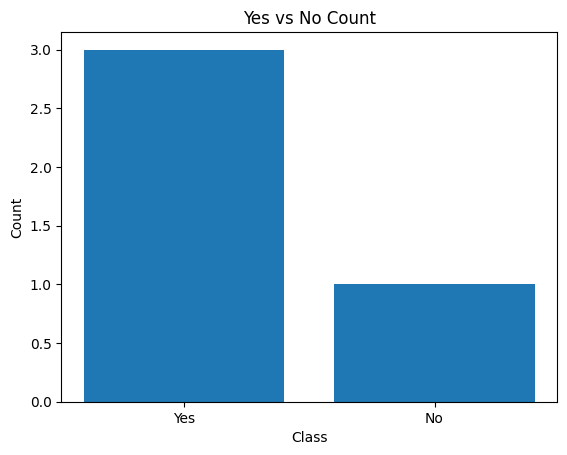

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Load dataset
data = pd.read_csv("1st_ml.csv")

# Count Yes / No
counts = data.iloc[:, -1].value_counts()

print(counts)

# Plot graph
plt.figure()
plt.bar(counts.index, counts.values)
plt.title("Yes vs No Count")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

2.For a given set of training data examples stored in a .CSV file, implement and demonstrate the
Candidate-Elimination algorithm in python to output a description of the set of all hypotheses
consistent with the training examples

In [ ]:
# Candidate-Elimination Algorithm in one cell

import pandas as pd
import numpy as np

# Step 1: Create dataset
data = {
"Sky": ["Sunny","Sunny","Rainy","Sunny","Rainy","Sunny"],
"Temp": ["Warm","Warm","Cold","Warm","Warm","Cold"],
"Humidity": ["Normal","High","High","High","Normal","Normal"],
"Wind": ["Strong","Strong","Strong","Strong","Weak","Strong"],
"Water": ["Warm","Warm","Warm","Cool","Warm","Warm"],
"Forecast": ["Same","Same","Change","Change","Same","Same"],
"Play": ["Yes","Yes","No","Yes","No","Yes"]
}

df = pd.DataFrame(data)

print("Dataset:\n")
print(df)

# Step 2: Convert dataset to list
data_list = df.values.tolist()

# Step 3: Initialize hypotheses
num_attr = len(data_list[0]) - 1

S = ['0'] * num_attr
G = ['?'] * num_attr

print("\nInitial Specific Hypothesis (S):", S)
print("Initial General Hypothesis (G):", G)

# Step 4: Candidate-Elimination training
for example in data_list:

    if example[-1] == "Yes":   # Positive example

        for i in range(num_attr):

            if S[i] == '0':
                S[i] = example[i]

            elif S[i] != example[i]:
                S[i] = '?'

        for i in range(num_attr):
            if G[i] != '?' and G[i] != example[i]:
                G[i] = '?'

    elif example[-1] == "No":  # Negative example

        for i in range(num_attr):

            if S[i] != example[i]:
                G[i] = S[i]

# Step 5: Print final hypotheses
print("\nFinal Specific Hypothesis (S):", S)
print("Final General Hypothesis (G):", G)

Dataset:

     Sky  Temp Humidity    Wind Water Forecast Play
0  Sunny  Warm   Normal  Strong  Warm     Same  Yes
1  Sunny  Warm     High  Strong  Warm     Same  Yes
2  Rainy  Cold     High  Strong  Warm   Change   No
3  Sunny  Warm     High  Strong  Cool   Change  Yes
4  Rainy  Warm   Normal    Weak  Warm     Same   No
5  Sunny  Cold   Normal  Strong  Warm     Same  Yes

Initial Specific Hypothesis (S): ['0', '0', '0', '0', '0', '0']
Initial General Hypothesis (G): ['?', '?', '?', '?', '?', '?']

Final Specific Hypothesis (S): ['Sunny', '?', '?', 'Strong', '?', '?']
Final General Hypothesis (G): ['Sunny', '?', '?', 'Strong', '?', '?']


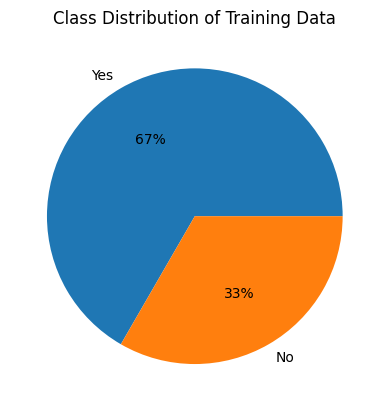

In [ ]:
import matplotlib.pyplot as plt

counts = df['Play'].value_counts()

plt.figure()
plt.pie(counts.values, labels=counts.index, autopct='%1.0f%%')
plt.title("Class Distribution of Training Data")
plt.show()

3.Demonstrate the working of the decision tree based ID3 algorithm. Use an appropriate data set
for building the decision tree and apply this knowledge to classify a new sample.

Dataset:

         Sky  Temp Humidity    Wind PlayTennis
0      Sunny   Hot     High    Weak         No
1      Sunny   Hot     High  Strong         No
2   Overcast   Hot     High    Weak        Yes
3       Rain  Mild     High    Weak        Yes
4       Rain  Cool   Normal    Weak        Yes
5       Rain  Cool   Normal  Strong         No
6   Overcast  Mild   Normal  Strong        Yes
7      Sunny   Hot     High    Weak         No
8      Sunny  Cool   Normal    Weak        Yes
9       Rain  Mild   Normal    Weak        Yes
10     Sunny  Mild   Normal  Strong        Yes
11  Overcast  Mild     High  Strong        Yes
12  Overcast   Hot   Normal    Weak        Yes
13      Rain  Mild     High  Strong         No


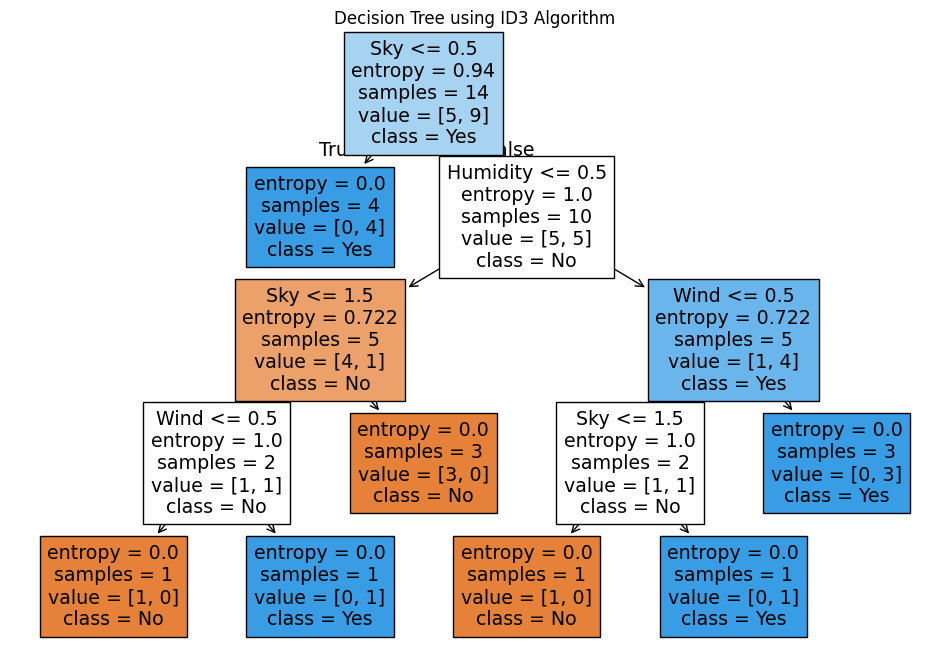


Prediction for new sample: Yes


In [ ]:
# Decision Tree (ID3) Demonstration with Graphical Representation

import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Step 1: Create Dataset
data = {
"Sky": ["Sunny","Sunny","Overcast","Rain","Rain","Rain","Overcast","Sunny","Sunny","Rain","Sunny","Overcast","Overcast","Rain"],
"Temp": ["Hot","Hot","Hot","Mild","Cool","Cool","Mild","Hot","Cool","Mild","Mild","Mild","Hot","Mild"],
"Humidity": ["High","High","High","High","Normal","Normal","Normal","High","Normal","Normal","Normal","High","Normal","High"],
"Wind": ["Weak","Strong","Weak","Weak","Weak","Strong","Strong","Weak","Weak","Weak","Strong","Strong","Weak","Strong"],
"PlayTennis": ["No","No","Yes","Yes","Yes","No","Yes","No","Yes","Yes","Yes","Yes","Yes","No"]
}

df = pd.DataFrame(data)

print("Dataset:\n")
print(df)

# Step 2: Encode categorical data
le = LabelEncoder()

df_encoded = df.apply(le.fit_transform)

X = df_encoded.drop("PlayTennis", axis=1)
y = df_encoded["PlayTennis"]

# Step 3: Train Decision Tree using entropy (ID3 concept)
model = DecisionTreeClassifier(criterion="entropy")
model.fit(X, y)

# Step 4: Graphical Representation of Decision Tree
plt.figure(figsize=(12,8))
plot_tree(model,
          feature_names=X.columns,
          class_names=["No","Yes"],
          filled=True)

plt.title("Decision Tree using ID3 Algorithm")
plt.show()

# Step 5: Classify a new sample
# Example: Sunny, Cool, High, Strong

new_sample = pd.DataFrame([["Sunny","Cool","High","Strong"]],
                          columns=["Sky","Temp","Humidity","Wind"])

# Encode new sample
for col in new_sample.columns:
    new_sample[col] = le.fit_transform(new_sample[col])

prediction = model.predict(new_sample)

print("\nPrediction for new sample:", "Yes" if prediction[0]==1 else "No")

4.Build an Artificial Neural Network by implementing the Backpropagation algorithm and test the
same using appropriate data sets.

Dataset shape: (150, 4)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Model Accuracy: 1.0


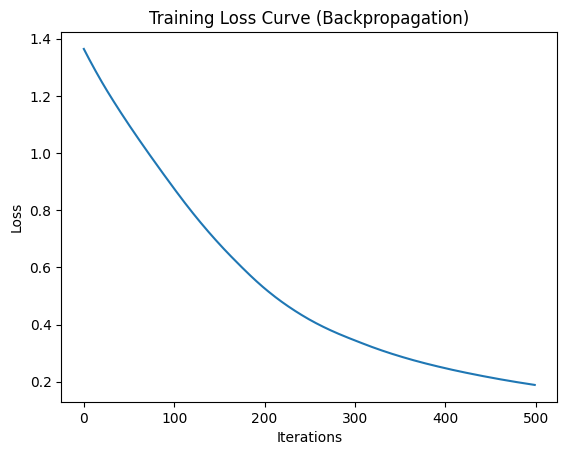

Prediction for new sample: setosa


In [ ]:
# Artificial Neural Network using Backpropagation

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Step 1: Load Dataset (Iris dataset)
data = load_iris()
X = data.data
y = data.target

print("Dataset shape:", X.shape)

# Step 2: Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 4: Build ANN model
# hidden_layer_sizes = neurons in hidden layer
model = MLPClassifier(hidden_layer_sizes=(10,),
                      activation='relu',
                      solver='adam',
                      max_iter=500,
                      random_state=42)

# Step 5: Train model (Backpropagation happens internally)
model.fit(X_train, y_train)

# Step 6: Predict test data
y_pred = model.predict(X_test)

# Step 7: Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

# Step 8: Graphical Representation (Loss Curve)
plt.figure()
plt.plot(model.loss_curve_)
plt.title("Training Loss Curve (Backpropagation)")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

# Step 9: Test with a new sample
sample = [[5.1, 3.5, 1.4, 0.2]]

sample = scaler.transform(sample)
prediction = model.predict(sample)

print("Prediction for new sample:", data.target_names[prediction][0])

5.Write a program for Implementation of K-Nearest Neighbours (K-NN) in Python

Dataset shape: (150, 4)
Model Accuracy: 1.0


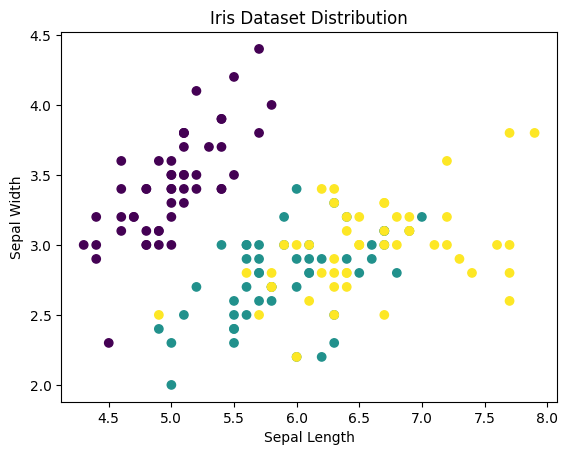

Prediction for new sample: setosa


In [ ]:
# Implementation of K-Nearest Neighbours (KNN)

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# Step 1: Load Dataset
data = load_iris()
X = data.data
y = data.target

print("Dataset shape:", X.shape)

# Step 2: Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Create KNN model
k = 3
model = KNeighborsClassifier(n_neighbors=k)

# Step 4: Train model
model.fit(X_train, y_train)

# Step 5: Predict test data
y_pred = model.predict(X_test)

# Step 6: Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

# Step 7: Graphical Representation (Feature Scatter Plot)
plt.figure()
plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Iris Dataset Distribution")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.show()

# Step 8: Classify a new sample
sample = [[5.1,3.5,1.4,0.2]]

prediction = model.predict(sample)

print("Prediction for new sample:", data.target_names[prediction][0])

6.Write a program to implement Naïve Bayes algorithm in python and to display the results using
confusion matrix and accuracy.

Dataset shape: (150, 4)
Model Accuracy: 1.0

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


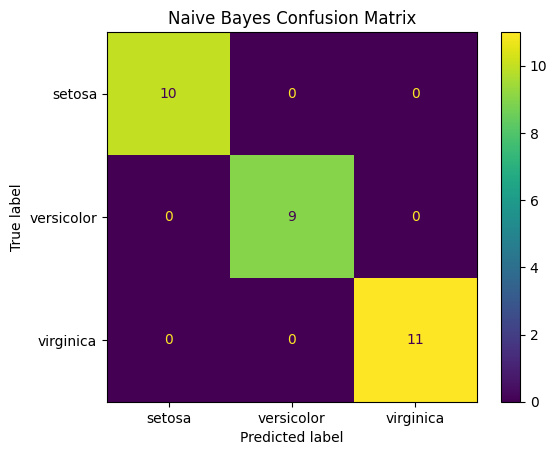

In [ ]:
# Naive Bayes Classification with Confusion Matrix and Accuracy

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

# Step 1: Load Dataset
data = load_iris()
X = data.data
y = data.target

print("Dataset shape:", X.shape)

# Step 2: Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Create Naive Bayes model
model = GaussianNB()

# Step 4: Train model
model.fit(X_train, y_train)

# Step 5: Predict test data
y_pred = model.predict(X_test)

# Step 6: Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

# Step 7: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n", cm)

# Step 8: Display Confusion Matrix Graphically
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)

disp.plot()
plt.title("Naive Bayes Confusion Matrix")
plt.show()

7.Write a program to implement Logistic Regression (LR) algorithm in python

Dataset shape: (150, 4)
Model Accuracy: 1.0


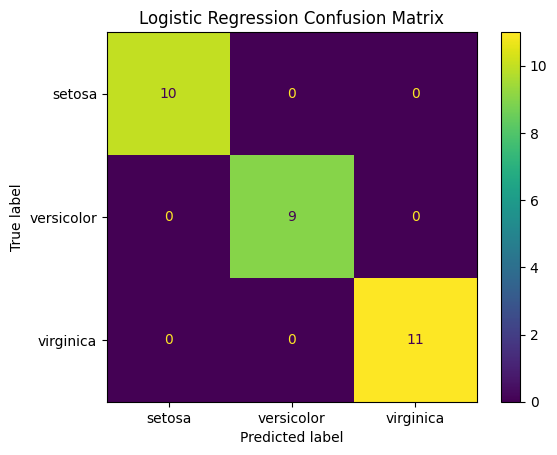

Prediction for new sample: setosa


In [ ]:
# Logistic Regression Implementation

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Step 1: Load dataset
data = load_iris()
X = data.data
y = data.target

print("Dataset shape:", X.shape)

# Step 2: Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Create Logistic Regression model
model = LogisticRegression(max_iter=200)

# Step 4: Train model
model.fit(X_train, y_train)

# Step 5: Predict test data
y_pred = model.predict(X_test)

# Step 6: Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

# Step 7: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Step 8: Test with new sample
sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(sample)

print("Prediction for new sample:", data.target_names[prediction][0])

8.Write a program to implement Linear Regression (LR) algorithm in python

Input Data (Hours): [1 2 3 4 5 6]
Output Data (Marks): [50 55 65 70 80 90]

Predicted Marks: [48.33333333 56.33333333 64.33333333 72.33333333 80.33333333 88.33333333]
Mean Squared Error: 2.222222222222222


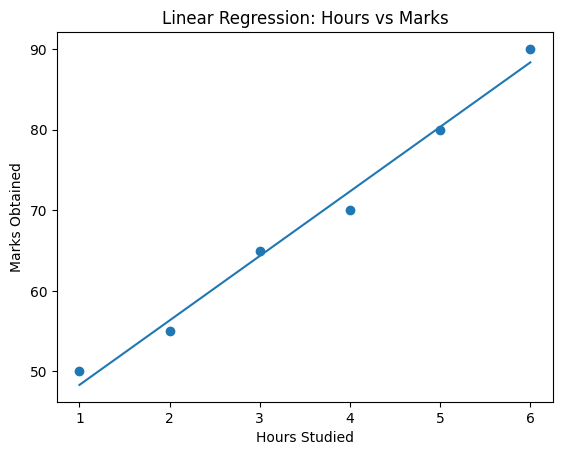

Predicted Marks for 7 hours study: 96.33333333333333


In [ ]:
# Linear Regression Implementation

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Step 1: Create dataset
# Example: Hours studied vs Marks obtained

X = np.array([1,2,3,4,5,6]).reshape(-1,1)
y = np.array([50,55,65,70,80,90])

print("Input Data (Hours):", X.flatten())
print("Output Data (Marks):", y)

# Step 2: Create Linear Regression model
model = LinearRegression()

# Step 3: Train the model
model.fit(X, y)

# Step 4: Predict values
y_pred = model.predict(X)

print("\nPredicted Marks:", y_pred)

# Step 5: Calculate Mean Squared Error
mse = mean_squared_error(y, y_pred)
print("Mean Squared Error:", mse)

# Step 6: Graphical Representation
plt.figure()
plt.scatter(X, y)
plt.plot(X, y_pred)
plt.title("Linear Regression: Hours vs Marks")
plt.xlabel("Hours Studied")
plt.ylabel("Marks Obtained")
plt.show()

# Step 7: Predict new value
new_hours = [[7]]
prediction = model.predict(new_hours)

print("Predicted Marks for 7 hours study:", prediction[0])

9.Compare Linear and Polynomial Regression using Python

Linear Regression MSE: 1.01530612244898
Polynomial Regression MSE: 0.40136054421768713


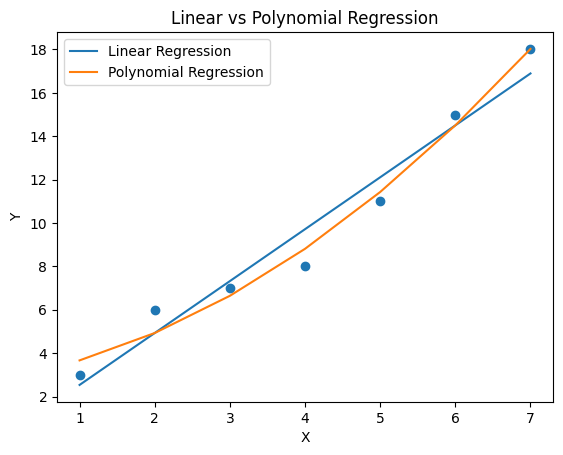

In [ ]:
# Comparison of Linear Regression and Polynomial Regression

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# Step 1: Create dataset
X = np.array([1,2,3,4,5,6,7]).reshape(-1,1)
y = np.array([3,6,7,8,11,15,18])

# Step 2: Linear Regression
linear_model = LinearRegression()
linear_model.fit(X, y)
y_linear = linear_model.predict(X)

# Step 3: Polynomial Regression
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)
y_poly = poly_model.predict(X_poly)

# Step 4: Calculate errors
mse_linear = mean_squared_error(y, y_linear)
mse_poly = mean_squared_error(y, y_poly)

print("Linear Regression MSE:", mse_linear)
print("Polynomial Regression MSE:", mse_poly)

# Step 5: Graphical comparison
plt.figure()

# Original data
plt.scatter(X, y)

# Linear Regression line
plt.plot(X, y_linear, label="Linear Regression")

# Polynomial Regression curve
plt.plot(X, y_poly, label="Polynomial Regression")

plt.title("Linear vs Polynomial Regression")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

10.Write a Python Program to Implement Expectation & Maximization Algorithm

Dataset shape: (300, 2)
Cluster Centers:
 [[-2.63323268  9.04356978]
 [-6.88387179 -6.98398415]
 [ 4.74710337  2.01059427]]


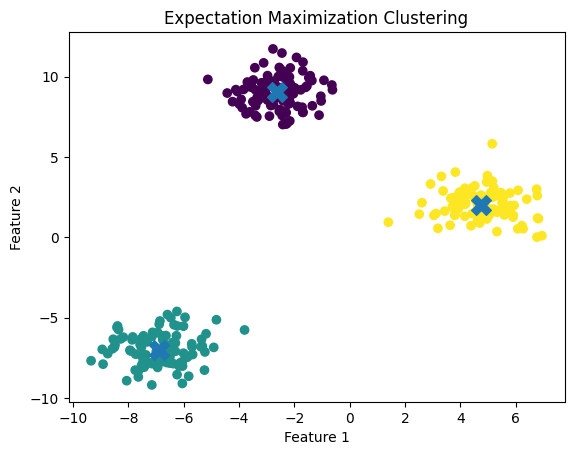

In [ ]:
# Expectation Maximization Algorithm using Gaussian Mixture Model

import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs

# Step 1: Generate dataset
X, y = make_blobs(n_samples=300, centers=3, random_state=42)

print("Dataset shape:", X.shape)

# Step 2: Apply EM algorithm using Gaussian Mixture Model
gmm = GaussianMixture(n_components=3, random_state=42)

# Step 3: Train model
gmm.fit(X)

# Step 4: Predict clusters
labels = gmm.predict(X)

# Step 5: Get cluster centers
centers = gmm.means_

print("Cluster Centers:\n", centers)

# Step 6: Graphical representation
plt.figure()

plt.scatter(X[:,0], X[:,1], c=labels)
plt.scatter(centers[:,0], centers[:,1], marker='X', s=200)

plt.title("Expectation Maximization Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

11.Write a program for the task of Credit Score Classification

Dataset:

   Income  LoanAmount  CreditHistory CreditScore
0   25000       10000              0        Poor
1   50000       20000              1     Average
2   75000       30000              1        Good
3  100000       40000              1        Good
4  120000       50000              1   Excellent
5   30000       15000              0        Poor
6   45000       25000              1     Average
7   80000       35000              1        Good
8   95000       45000              1   Excellent
9   60000       28000              1        Good

Model Accuracy: 0.5


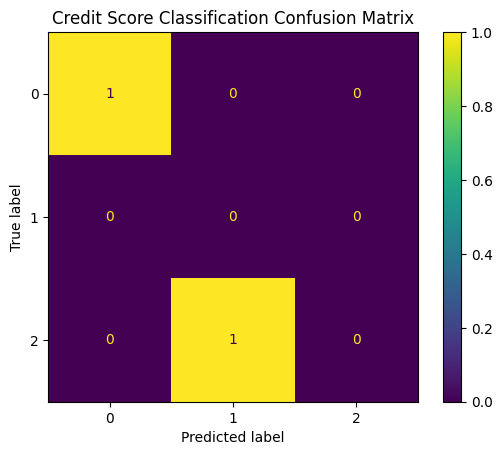


Predicted Credit Score: Good


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Credit Score Classification

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Step 1: Create Dataset
data = {
"Income":[25000,50000,75000,100000,120000,30000,45000,80000,95000,60000],
"LoanAmount":[10000,20000,30000,40000,50000,15000,25000,35000,45000,28000],
"CreditHistory":[0,1,1,1,1,0,1,1,1,1],
"CreditScore":["Poor","Average","Good","Good","Excellent","Poor","Average","Good","Excellent","Good"]
}

df = pd.DataFrame(data)

print("Dataset:\n")
print(df)

# Step 2: Convert labels to numbers
df["CreditScore"] = df["CreditScore"].map({"Poor":0,"Average":1,"Good":2,"Excellent":3})

# Step 3: Split dataset
X = df[["Income","LoanAmount","CreditHistory"]]
y = df["CreditScore"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Step 4: Train model
model = DecisionTreeClassifier()
model.fit(X_train,y_train)

# Step 5: Predict test data
y_pred = model.predict(X_test)

# Step 6: Accuracy
accuracy = accuracy_score(y_test,y_pred)
print("\nModel Accuracy:",accuracy)

# Step 7: Confusion Matrix
cm = confusion_matrix(y_test,y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Credit Score Classification Confusion Matrix")
plt.show()

# Step 8: Predict new sample
sample = [[70000,30000,1]]

prediction = model.predict(sample)

score_labels = {0:"Poor",1:"Average",2:"Good",3:"Excellent"}

print("\nPredicted Credit Score:",score_labels[prediction[0]])

12.Implement Iris Flower Classification using KNN

Dataset shape: (150, 4)
Model Accuracy: 1.0


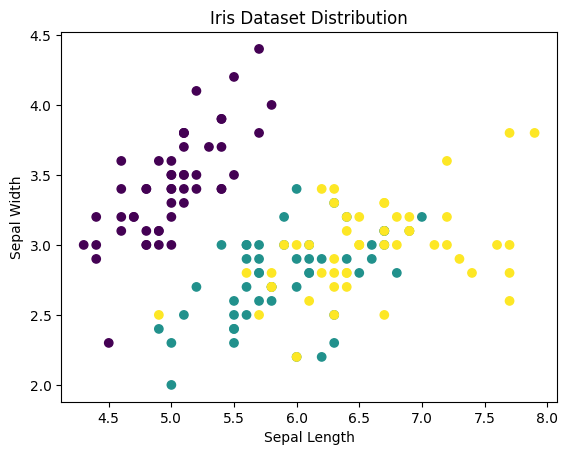

Predicted Flower: setosa


In [ ]:
# Iris Flower Classification using KNN

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# Step 1: Load dataset
iris = load_iris()

X = iris.data
y = iris.target

print("Dataset shape:", X.shape)

# Step 2: Split dataset
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Step 3: Create KNN model
k = 3
model = KNeighborsClassifier(n_neighbors=k)

# Step 4: Train model
model.fit(X_train,y_train)

# Step 5: Predict test data
y_pred = model.predict(X_test)

# Step 6: Accuracy
accuracy = accuracy_score(y_test,y_pred)
print("Model Accuracy:",accuracy)

# Step 7: Graphical Representation
plt.figure()
plt.scatter(X[:,0],X[:,1],c=y)
plt.title("Iris Dataset Distribution")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.show()

# Step 8: Predict new sample
sample = [[5.1,3.5,1.4,0.2]]

prediction = model.predict(sample)

print("Predicted Flower:", iris.target_names[prediction][0])

13.Implement the Car Price Prediction Model using Python

Dataset:

   Year  EngineSize  Mileage   Price
0  2015         1.2    20000  500000
1  2016         1.5    18000  550000
2  2017         1.3    15000  600000
3  2018         1.6    12000  650000
4  2019         1.8    10000  700000
5  2020         2.0     8000  750000
6  2021         2.2     5000  820000
7  2022         2.5     3000  900000

Model R2 Score: 0.9324388705654747


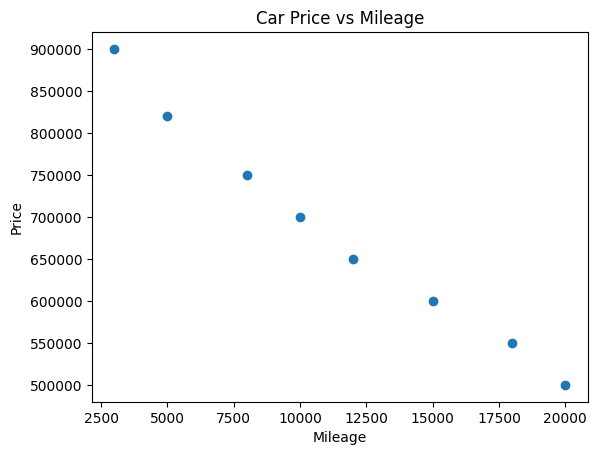


Predicted Car Price: 996045.0160768926


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
# Car Price Prediction using Linear Regression

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Step 1: Create dataset
data = {
"Year":[2015,2016,2017,2018,2019,2020,2021,2022],
"EngineSize":[1.2,1.5,1.3,1.6,1.8,2.0,2.2,2.5],
"Mileage":[20000,18000,15000,12000,10000,8000,5000,3000],
"Price":[500000,550000,600000,650000,700000,750000,820000,900000]
}

df = pd.DataFrame(data)

print("Dataset:\n")
print(df)

# Step 2: Select features and target
X = df[["Year","EngineSize","Mileage"]]
y = df["Price"]

# Step 3: Split dataset
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Step 4: Train model
model = LinearRegression()
model.fit(X_train,y_train)

# Step 5: Predict prices
y_pred = model.predict(X_test)

# Step 6: Accuracy
score = r2_score(y_test,y_pred)
print("\nModel R2 Score:",score)

# Step 7: Graphical representation
plt.figure()
plt.scatter(df["Mileage"],df["Price"])
plt.title("Car Price vs Mileage")
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.show()

# Step 8: Predict price for new car
sample = [[2023,2.0,4000]]

prediction = model.predict(sample)

print("\nPredicted Car Price:",prediction[0])

14.Implement House price Prediction using appropriate machine learning algorithm

Dataset:

   Area  Bedrooms  Age    Price
0   600         1   10  2000000
1   800         2    8  3000000
2  1000         2    6  3500000
3  1200         3    5  4500000
4  1500         3    4  5500000
5  1800         4    3  6500000
6  2000         4    2  7500000
7  2200         5    1  8500000

Model R2 Score: 0.9783423573511038


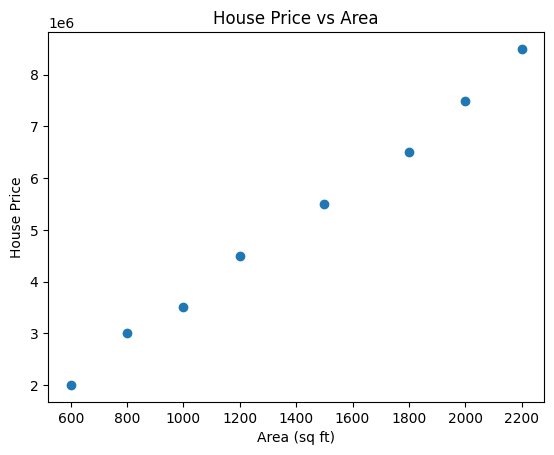


Predicted House Price: 5785714.285714285


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
# House Price Prediction using Linear Regression

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Step 1: Create dataset
data = {
"Area":[600,800,1000,1200,1500,1800,2000,2200],
"Bedrooms":[1,2,2,3,3,4,4,5],
"Age":[10,8,6,5,4,3,2,1],
"Price":[2000000,3000000,3500000,4500000,5500000,6500000,7500000,8500000]
}

df = pd.DataFrame(data)

print("Dataset:\n")
print(df)

# Step 2: Define features and target
X = df[["Area","Bedrooms","Age"]]
y = df["Price"]

# Step 3: Split dataset
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Step 4: Train model
model = LinearRegression()
model.fit(X_train,y_train)

# Step 5: Predict test data
y_pred = model.predict(X_test)

# Step 6: Accuracy
score = r2_score(y_test,y_pred)
print("\nModel R2 Score:",score)

# Step 7: Graphical Representation
plt.figure()
plt.scatter(df["Area"],df["Price"])
plt.title("House Price vs Area")
plt.xlabel("Area (sq ft)")
plt.ylabel("House Price")
plt.show()

# Step 8: Predict price for new house
sample = [[1600,3,3]]

prediction = model.predict(sample)

print("\nPredicted House Price:",prediction[0])

15.Implement Iris Flower Classification using Naive Bayes classifier

Dataset shape: (150, 4)
Model Accuracy: 1.0


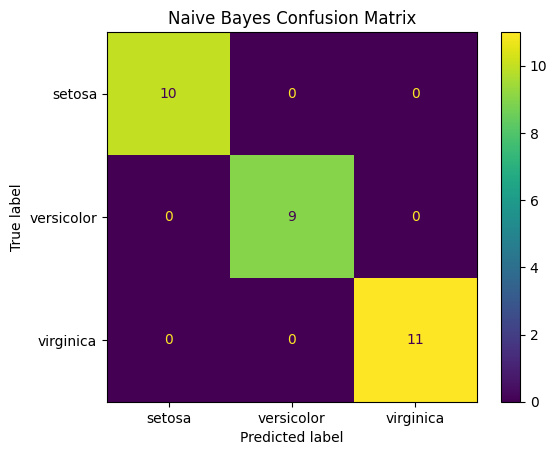

Predicted Flower: setosa


In [ ]:
# Iris Flower Classification using Naive Bayes

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Step 1: Load dataset
iris = load_iris()

X = iris.data
y = iris.target

print("Dataset shape:", X.shape)

# Step 2: Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Create Naive Bayes model
model = GaussianNB()

# Step 4: Train model
model.fit(X_train, y_train)

# Step 5: Predict test data
y_pred = model.predict(X_test)

# Step 6: Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

# Step 7: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot()

plt.title("Naive Bayes Confusion Matrix")
plt.show()

# Step 8: Predict new sample
sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(sample)

print("Predicted Flower:", iris.target_names[prediction][0])

16.Compare different types Classification Algorithms and evaluate their performance.

Logistic Regression Accuracy: 1.0
KNN Accuracy: 1.0
Decision Tree Accuracy: 1.0
Naive Bayes Accuracy: 1.0


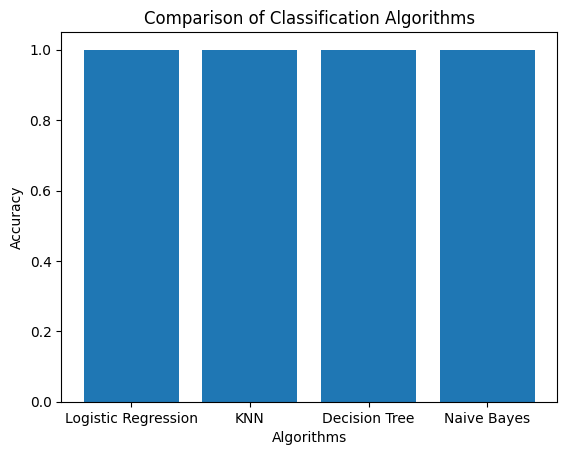

In [ ]:
# Comparison of Classification Algorithms

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# Step 1: Load dataset
data = load_iris()
X = data.data
y = data.target

# Step 2: Split dataset
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Step 3: Create models
models = {
"Logistic Regression": LogisticRegression(max_iter=200),
"KNN": KNeighborsClassifier(n_neighbors=3),
"Decision Tree": DecisionTreeClassifier(),
"Naive Bayes": GaussianNB()
}

accuracies = []

# Step 4: Train and evaluate models
for name, model in models.items():

    model.fit(X_train,y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test,y_pred)

    accuracies.append(acc)

    print(name,"Accuracy:",acc)

# Step 5: Graphical comparison
plt.figure()

plt.bar(models.keys(),accuracies)

plt.title("Comparison of Classification Algorithms")
plt.xlabel("Algorithms")
plt.ylabel("Accuracy")

plt.show()

17.Implement Mobile Price Prediction using appropriate machine learning algorithm

Dataset:

   RAM  Storage  Battery  Camera  PriceRange
0    2       16     3000       8           0
1    3       32     3200      12           1
2    4       64     3500      16           2
3    6       64     4000      20           2
4    8      128     4500      24           3
5   12      256     5000      48           3
6    4       32     3300      12           1
7    6       64     4200      16           2
8    8      128     4700      32           3
9   12      256     5200      64           3

Model Accuracy: 1.0


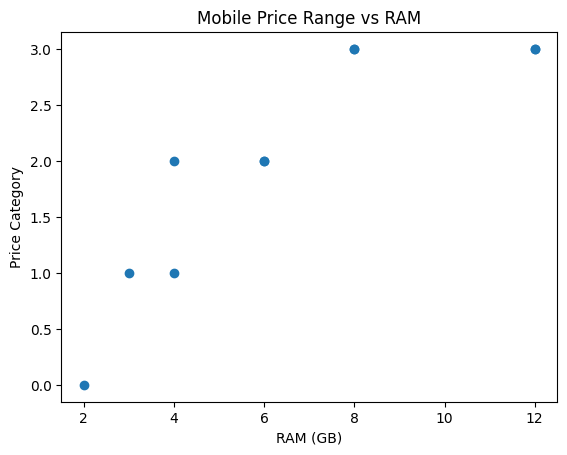


Predicted Mobile Price Category: 3


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Mobile Price Prediction using Decision Tree

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Step 1: Create dataset
data = {
"RAM":[2,3,4,6,8,12,4,6,8,12],
"Storage":[16,32,64,64,128,256,32,64,128,256],
"Battery":[3000,3200,3500,4000,4500,5000,3300,4200,4700,5200],
"Camera":[8,12,16,20,24,48,12,16,32,64],
"PriceRange":[0,1,2,2,3,3,1,2,3,3]
}

df = pd.DataFrame(data)

print("Dataset:\n")
print(df)

# Step 2: Features and target
X = df[["RAM","Storage","Battery","Camera"]]
y = df["PriceRange"]

# Step 3: Split dataset
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Step 4: Train model
model = DecisionTreeClassifier()
model.fit(X_train,y_train)

# Step 5: Predict test data
y_pred = model.predict(X_test)

# Step 6: Accuracy
accuracy = accuracy_score(y_test,y_pred)
print("\nModel Accuracy:",accuracy)

# Step 7: Graphical Representation
plt.figure()
plt.scatter(df["RAM"],df["PriceRange"])
plt.title("Mobile Price Range vs RAM")
plt.xlabel("RAM (GB)")
plt.ylabel("Price Category")
plt.show()

# Step 8: Predict new mobile
sample = [[8,128,4500,32]]

prediction = model.predict(sample)

print("\nPredicted Mobile Price Category:",prediction[0])

18.Implement Perceptron based IRIS classification

Dataset shape: (150, 4)
Model Accuracy: 0.8


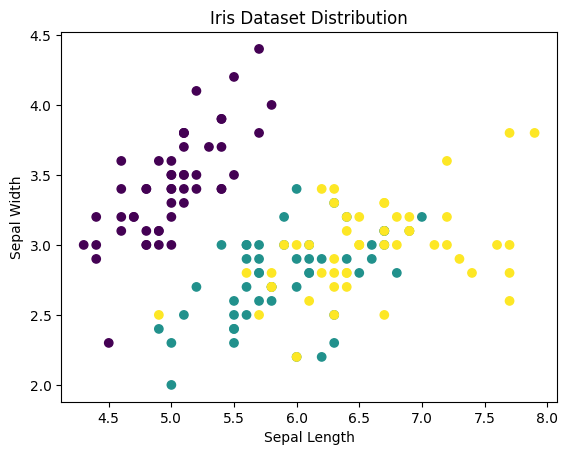

Predicted Flower: setosa


In [ ]:
# Perceptron Based Iris Classification

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score
import numpy as np

# Step 1: Load dataset
iris = load_iris()

X = iris.data
y = iris.target

print("Dataset shape:", X.shape)

# Step 2: Split dataset
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Step 3: Create Perceptron model
model = Perceptron(max_iter=1000)

# Step 4: Train model
model.fit(X_train,y_train)

# Step 5: Predict test data
y_pred = model.predict(X_test)

# Step 6: Accuracy
accuracy = accuracy_score(y_test,y_pred)
print("Model Accuracy:",accuracy)

# Step 7: Graphical Representation
plt.figure()
plt.scatter(X[:,0],X[:,1],c=y)
plt.title("Iris Dataset Distribution")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.show()

# Step 8: Predict new sample
sample = [[5.1,3.5,1.4,0.2]]

prediction = model.predict(sample)

print("Predicted Flower:", iris.target_names[prediction][0])

19.Implementation of Naive Bayes classification for Bank Loan prediction

Dataset:

   Income  CreditScore  LoanAmount  LoanApproved
0   25000          550       10000             0
1   30000          600       15000             0
2   40000          650       20000             0
3   50000          700       25000             1
4   60000          720       30000             1
5   70000          750       35000             1
6   80000          780       40000             1
7   90000          800       45000             1
8  100000          820       50000             1
9  120000          850       55000             1

Model Accuracy: 1.0


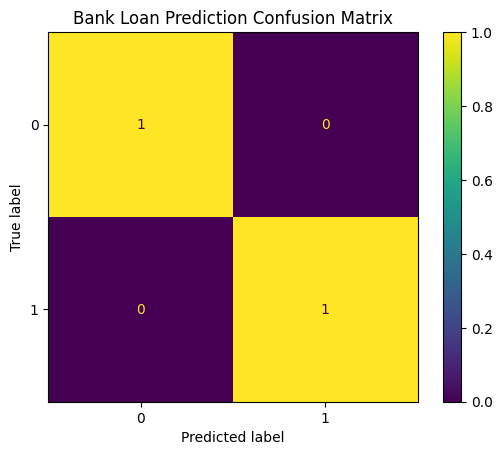


Loan Approval Prediction: Approved


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [ ]:
# Bank Loan Prediction using Naive Bayes

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Step 1: Create dataset
data = {
"Income":[25000,30000,40000,50000,60000,70000,80000,90000,100000,120000],
"CreditScore":[550,600,650,700,720,750,780,800,820,850],
"LoanAmount":[10000,15000,20000,25000,30000,35000,40000,45000,50000,55000],
"LoanApproved":[0,0,0,1,1,1,1,1,1,1]
}

df = pd.DataFrame(data)

print("Dataset:\n")
print(df)

# Step 2: Features and target
X = df[["Income","CreditScore","LoanAmount"]]
y = df["LoanApproved"]

# Step 3: Split dataset
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Step 4: Train model
model = GaussianNB()
model.fit(X_train,y_train)

# Step 5: Predict test data
y_pred = model.predict(X_test)

# Step 6: Accuracy
accuracy = accuracy_score(y_test,y_pred)
print("\nModel Accuracy:",accuracy)

# Step 7: Confusion Matrix
cm = confusion_matrix(y_test,y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Bank Loan Prediction Confusion Matrix")
plt.show()

# Step 8: Predict new applicant
sample = [[65000,720,30000]]

prediction = model.predict(sample)

print("\nLoan Approval Prediction:", "Approved" if prediction[0]==1 else "Rejected")

20.Implement Future Sales Prediction using a suitable machine learning algorithm

Dataset:

   Month  Sales
0      1    200
1      2    220
2      3    250
3      4    270
4      5    300
5      6    320
6      7    350
7      8    370
8      9    400
9     10    420

Model R2 Score: 0.9988116458704694


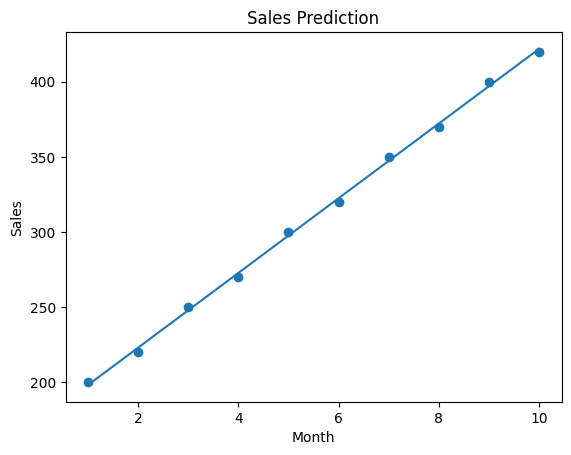


Predicted Sales for Month 11: 446.66666666666674


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
# Future Sales Prediction using Linear Regression

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# Step 1: Create dataset (Month vs Sales)
data = {
"Month":[1,2,3,4,5,6,7,8,9,10],
"Sales":[200,220,250,270,300,320,350,370,400,420]
}

df = pd.DataFrame(data)

print("Dataset:\n")
print(df)

# Step 2: Features and target
X = df[["Month"]]
y = df["Sales"]

# Step 3: Train model
model = LinearRegression()
model.fit(X,y)

# Step 4: Predict existing values
y_pred = model.predict(X)

# Step 5: Model accuracy
score = r2_score(y,y_pred)
print("\nModel R2 Score:",score)

# Step 6: Graphical representation
plt.figure()
plt.scatter(df["Month"],df["Sales"])
plt.plot(df["Month"],y_pred)
plt.title("Sales Prediction")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

# Step 7: Predict future sales
future_month = [[11]]
prediction = model.predict(future_month)

print("\nPredicted Sales for Month 11:",prediction[0])